In [263]:
import math
import json
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('./graph_preset.mplstyle')


In [264]:
def _restore_hdf5_columns(dataset):
    """Return DataFrame column names stored in an HDF5 dataset, if available."""
    cols_attr = dataset.attrs.get("columns", None)
    if cols_attr is None:
        return None
    if isinstance(cols_attr, (bytes, np.bytes_)):
        cols_attr = cols_attr.decode("utf-8")
    return json.loads(cols_attr)


def load_hdf5_datasets(h5_path, *, verbose=True):
    """Load every HDF5 dataset into a dictionary of pandas DataFrames.

    The keys are HDF5 dataset paths such as ``output/validation_samples``
    and ``output/validation_summary``. If the dataset has a JSON ``columns`` attribute, it is
    used to restore DataFrame column names.
    """
    h5_path = Path(h5_path)
    datasets = {}

    def store_dataset(name, obj):
        if not isinstance(obj, h5py.Dataset):
            return
        if verbose:
            print(f"  Loading: {name} | Shape: {obj.shape}")
        columns = _restore_hdf5_columns(obj)
        datasets[name] = pd.DataFrame(obj[:], columns=columns)

    with h5py.File(h5_path, "r") as f:
        if verbose:
            print(f"--- Loading all datasets from {h5_path} ---")
        f.visititems(store_dataset)
        if verbose:
            print("---------------------------------------------")
            print("\n--- Dictionary Keys ---")
            print(list(datasets.keys()))
            print("-----------------------")

    return datasets


def show_hdf5_structure(h5_path):
    """Print groups, datasets, shapes, and dtypes in an HDF5 result file."""
    h5_path = Path(h5_path)
    with h5py.File(h5_path, "r") as f:
        print(f"--- Structure of {h5_path} ---")

        def print_structure(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"  {name} (Dataset) | Shape: {obj.shape}, Dtype: {obj.dtype}")
            elif isinstance(obj, h5py.Group):
                print(f"  {name} (Group)")

        f.visititems(print_structure)
        print("---------------------------------")


def _select_existing_columns(df, columns):
    """Return only requested columns that exist, preserving order."""
    missing = [column for column in columns if column not in df.columns]
    if missing:
        raise KeyError(f"Columns {missing} were not found. Available columns: {list(df.columns)}")
    return df[list(columns)].copy()


def _ordered_validation_columns(df, *, param_names=None, output_columns=None, metadata_columns=("sample_idx", "sim_id", "center_distance_l2")):
    """Return validation.ipynb-compatible column order for output/validation_samples."""
    if param_names is None:
        return list(df.columns)

    columns = list(param_names)
    if output_columns is not None:
        columns.extend(column for column in output_columns if column not in columns)

    for column in metadata_columns:
        if column in df.columns and column not in columns:
            columns.append(column)
    return columns


def make_validation_dataframe(
    datasets,
    *,
    validation_key="output/validation_samples",
    param_names=None,
    output_columns=("S11",),
    metadata_columns=("sample_idx", "sim_id", "center_distance_l2"),
):
    """Load the evaluated validation samples produced by ``validation.ipynb``.

    ``validation.ipynb`` writes a single numeric log to
    ``output/validation_samples``. That dataset already contains the rounded
    input parameter columns and the evaluated ``S11`` value, so this notebook
    should not look for or join paired ``input/repeat_*`` and
    ``output/repeat_*`` datasets.

    Parameters
    ----------
    datasets : dict[str, pandas.DataFrame]
        Dictionary returned by ``load_hdf5_datasets``.
    validation_key : str
        HDF5 dataset key containing the validation sample log.
    param_names : sequence[str] or None
        Optional parameter columns to keep and order. When ``None``, all
        columns in ``validation_key`` are preserved.
    output_columns : sequence[str] or None
        Optional output columns to keep and order after ``param_names``; the
        default matches ``validation.ipynb``'s ``S11`` output.
    metadata_columns : sequence[str]
        Validation bookkeeping columns to keep after parameter/output columns
        when they exist.
    """
    if validation_key not in datasets:
        available_keys = sorted(datasets.keys())
        raise KeyError(
            f"Validation dataset {validation_key!r} was not found. "
            f"Run validation.ipynb first and confirm the HDF5 file contains "
            f"{validation_key!r}. Available keys: {available_keys}"
        )

    df = datasets[validation_key].reset_index(drop=True).copy()
    columns = _ordered_validation_columns(
        df,
        param_names=param_names,
        output_columns=output_columns,
        metadata_columns=metadata_columns,
    )
    return _select_existing_columns(df, columns)


def infer_parameter_columns(df, *, param_names=None, x_center=None, value_column="S11", exclude_columns=("sample_idx", "sim_id", "center_distance_l2")):
    """Infer validation parameter columns from a DataFrame."""
    if param_names is not None:
        return list(param_names)

    numeric_columns = [column for column in df.select_dtypes(include=[np.number]).columns if column != value_column]
    numeric_columns = [column for column in numeric_columns if column not in set(exclude_columns)]
    if x_center is not None and len(numeric_columns) >= len(x_center):
        return numeric_columns[: len(x_center)]
    return numeric_columns


def plot_validation_histograms(
    *,
    validation_df=None,
    param_names=None,
    x_center=None,
    z_validation=None,
    s11_values=None,
    value_column="S11",
    value_label=None,
    n_cols=4,
    bins="auto",
    figsize_per_axis=(4.2, 3.0),
    show=True,
):
    """Plot parameter perturbation histograms and an optional value histogram.

    This function prioritizes ``validation_df`` because it should contain the
    actually evaluated, rounded validation inputs. If no evaluated DataFrame is
    available, pass ``z_validation`` to inspect the planned perturbations; in
    that case the value histogram is skipped unless ``s11_values`` is provided.
    """
    if x_center is None:
        raise ValueError("x_center must be provided to plot perturbations around x_optima.")
    x_center = np.asarray(x_center, dtype=float)
    value_label = value_label or value_column

    has_validation_df = validation_df is not None and not validation_df.empty
    if has_validation_df:
        param_names = infer_parameter_columns(validation_df, param_names=param_names, x_center=x_center, value_column=value_column)
        if len(param_names) != len(x_center):
            raise ValueError(f"len(param_names)={len(param_names)} must match len(x_center)={len(x_center)}.")
        perturbation_values = validation_df[param_names].to_numpy(dtype=float) - x_center
        if value_column in validation_df.columns:
            s11_values = validation_df[value_column].to_numpy(dtype=float)
    else:
        if z_validation is None:
            raise ValueError("Provide either a non-empty validation_df or z_validation.")
        perturbation_values = np.asarray(z_validation, dtype=float) - x_center
        if param_names is None:
            param_names = [f"x{i}" for i in range(perturbation_values.shape[1])]
        else:
            param_names = list(param_names)

    n_params = len(param_names)
    n_cols = min(n_cols, max(n_params, 1))
    n_rows = math.ceil(n_params / n_cols)

    fig_width = figsize_per_axis[0] * n_cols
    fig_height = figsize_per_axis[1] * n_rows
    fig_params, axes_params = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_width, fig_height),
        constrained_layout=True,
        squeeze=False,
    )
    axes_flat = axes_params.reshape(-1)

    for idx, (ax, param_name) in enumerate(zip(axes_flat, param_names)):
        values = perturbation_values[:, idx]
        ax.hist(values, bins=bins, edgecolor="black", alpha=0.75)
        ax.axvline(0.0, color="tab:red", linestyle="--", linewidth=1.5, label="x_optima")
        ax.set_title(param_name)
        ax.set_xlabel(f"{param_name} - x_optima")
        ax.set_ylabel("count")
        ax.grid(alpha=0.25)
        ax.legend(loc="best")

    for ax in axes_flat[n_params:]:
        ax.axis("off")

    fig_params.suptitle("Perturbation histograms around x_optima", fontsize=16)
    if show:
        plt.show()

    fig_value = None
    axes_value = None
    expected_value = None
    if s11_values is None:
        print(f"{value_label} histogram is skipped because evaluated values are not available yet.")
    else:
        values = np.asarray(s11_values, dtype=float)
        expected_value = float(np.mean(values))
        centered_values = values #- expected_value

        fig_value, axes_value = plt.subplots(figsize=(8, 6), constrained_layout=True)
        axes_value.hist(centered_values, bins=bins, edgecolor="black", alpha=0.75, label="Averaged S11")
        #axes_value.axvline(
        #    0.0,
        #    color="tab:red",
        #    linestyle="--",
        #    linewidth=1.5,
        #    label=f"E[{value_label}] = {expected_value:.6g}",
        #)
        axes_value.set_xlabel(f"{value_label}")# - E[{value_label}]")
        axes_value.set_ylabel("count")
        axes_value.grid(alpha=0.25)
        axes_value.legend(loc="best")
        if show:
            plt.show()

    return {
        "perturbation_fig": fig_params,
        "perturbation_axes": axes_params,
        "value_fig": fig_value,
        "value_axes": axes_value,
        "expected_value": expected_value,
        "param_names": param_names,
    }


In [265]:
read_path = Path("./0604001150/results.h5") # post-JPS 1%
#read_path = Path("./0603222139/results.h5") # robust 1%
read_path = Path("./0604053933/results.h5") # post-JPS 10%
read_path = Path("./0604071012/results.h5") # robust 10%



In [ ]:
# x_optima used as the center for validation perturbation histograms.
# read_path
x_center = np.asarray([
    6.225785,
    4.065235,
    9.188137,
    9.788713,
    1.000000,
    1.071733,
    2.000000,
    1.456739,
    1.835538,
    0.537034,
    2.000000,
    3.711260,
    6.000000,
], dtype=float)

x_center = np.asarray([
    6.226182,
    8.794176,
    3.161295,
    8.149709,
    7.147060,
    1.003729,
    1.371851,
    1.886560,
    0.923806,
    1.245569,
    2.031578,
    3.560018,
    4.278458,
], dtype=float)


In [267]:
show_hdf5_structure(read_path)


--- Structure of 0604071012\results.h5 ---
  input (Group)
  learning_curve (Group)
  output (Group)
  output/validation_samples (Dataset) | Shape: (100, 17), Dtype: float32
  output/validation_summary (Dataset) | Shape: (1, 5), Dtype: float32
---------------------------------


In [268]:
df_data = load_hdf5_datasets(read_path)


--- Loading all datasets from 0604071012\results.h5 ---
  Loading: output/validation_samples | Shape: (100, 17)
  Loading: output/validation_summary | Shape: (1, 5)
---------------------------------------------

--- Dictionary Keys ---
['output/validation_samples', 'output/validation_summary']
-----------------------


In [269]:
pd.set_option('display.max_rows', None)

In [270]:
# Inspect the validation log written by validation.ipynb.
#df_data.get("output/validation_samples")


In [271]:
# Load the evaluated validation DataFrame written by validation.ipynb.
# validation.ipynb stores rounded input parameters and S11 together in output/validation_samples.
validation_df = make_validation_dataframe(
    df_data,
    validation_key="output/validation_samples",
    param_names=globals().get("PARAM_NAMES"),
    output_columns=["S11"],
)
validation_df.head()


,h1,h2,h3,h4,h5,s1,s2,s3,s4,s5,a,b,k,S11,sim_id,sample_idx,center_distance_l2
0,6.597932,3.910392,9.371798,10.000000,1.530399,1.000000,2.000000,1.127046,1.977066,0.674584,2.301651,3.316184,4.982687,-21.649118,1.0,0.0,1.398915
1,6.170616,4.886962,9.018073,9.184912,1.000000,1.071200,1.718156,1.556942,2.000000,0.575678,2.000000,3.545214,5.781353,-28.525282,2.0,1.0,1.124799
2,6.570076,3.244027,8.470440,9.239724,1.147462,1.120504,2.000000,1.606841,1.678089,0.798942,2.744527,3.954126,6.000000,-21.825386,3.0,2.0,1.537121
3,6.957280,4.826799,8.814396,8.864964,1.000000,1.251797,2.000000,1.885229,1.624845,0.713462,3.225965,3.881384,5.294716,-16.419489,4.0,3.0,2.104509
4,6.057554,3.486343,9.443537,9.947799,1.000000,1.332965,2.000000,1.513493,1.673421,0.628424,2.000000,3.971714,6.000000,-15.747123,5.0,4.0,0.792394


In [272]:
min_pos = validation_df["S11"].idxmin()

print(f"Min S11: {validation_df.loc[min_pos, 'S11']}")
print(f"Location: {min_pos}")
print("That row:")
print(validation_df.loc[min_pos])


Min S11: -28.52528190612793
Location: 1
That row:
h1                     6.170616
h2                     4.886962
h3                     9.018073
h4                     9.184912
h5                     1.000000
s1                     1.071200
s2                     1.718156
s3                     1.556942
s4                     2.000000
s5                     0.575678
a                      2.000000
b                      3.545214
k                      5.781353
S11                  -28.525282
sim_id                 2.000000
sample_idx             1.000000
center_distance_l2     1.124799
Name: 1, dtype: float32


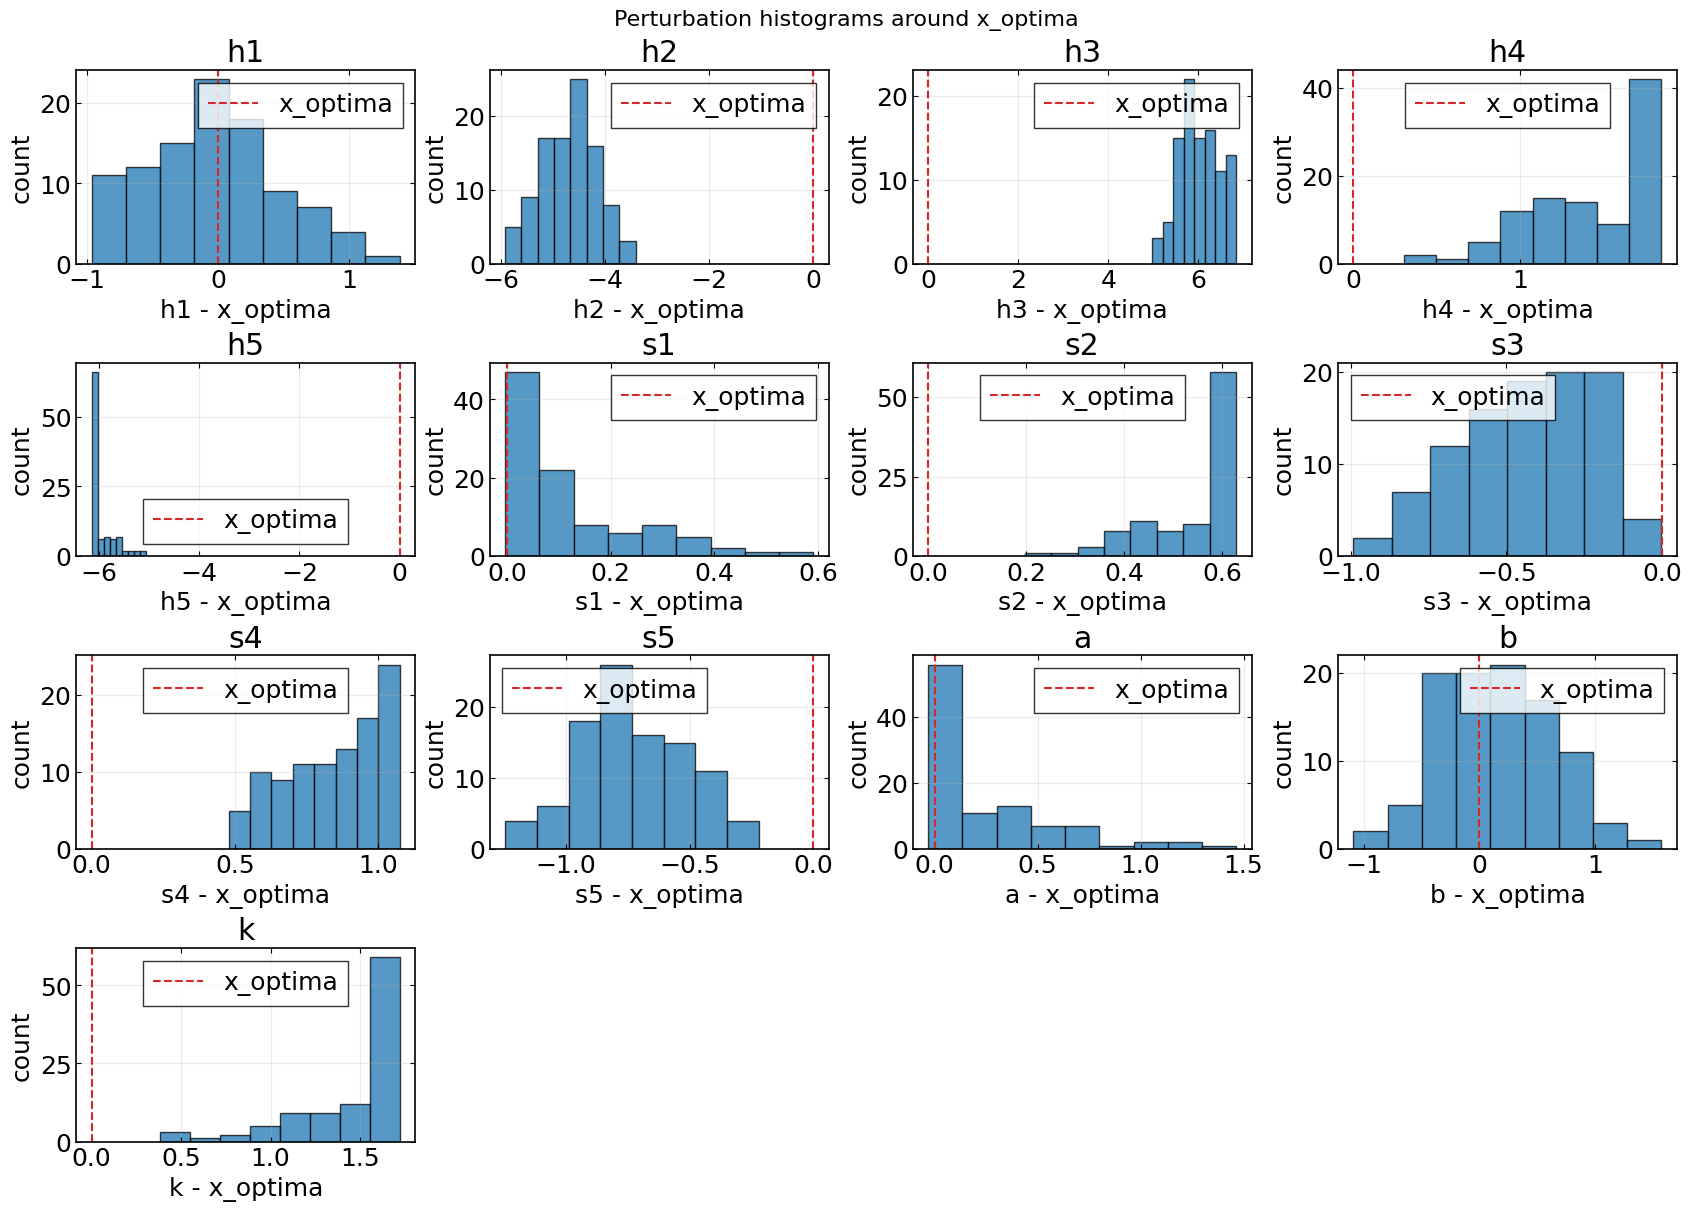

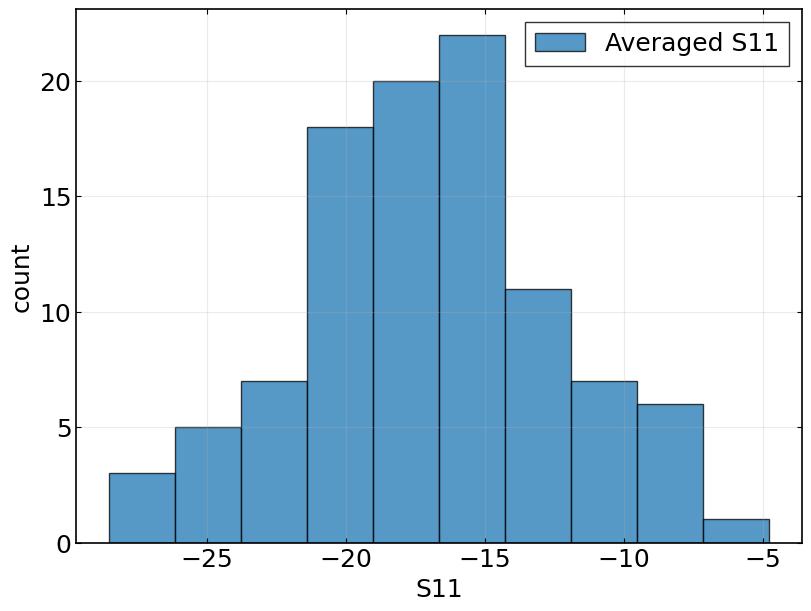

In [273]:
# Plot perturbation histograms around x_optima and the S11 histogram around E[S11].
# Required variables:
#   x_center: x_optima as a 1-D array/list
# Optional variables:
#   PARAM_NAMES: ordered parameter names
#   Z_validation: planned validation points; used only when validation_df is absent
hist_result = plot_validation_histograms(
    validation_df=globals().get("validation_df"),
    param_names=globals().get("PARAM_NAMES"),
    x_center=globals().get("x_center"),
    z_validation=globals().get("Z_validation"),
    value_column="S11",
)

